In [ ]:
import pandas as pd
import time

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
data = {
    'Hours_Studied': [2, 4, 6, 8, 10, 5, 7, 3, 9, 6],
    'Attendance': [75, 80, 85, 90, 95, 82, 88, 78, 92, 86],
    'Assignments': [4, 5, 6, 7, 8, 5, 6, 4, 7, 6],
    'Previous_Score': [32, 45, 58, 72, 88, 52, 68, 40, 80, 62],
    'Marks': [35,50,65,80,95,60,75,45,88,70],
}

In [ ]:
df = pd.DataFrame(data)

print("Correlation Matrix:")
correlation_matrix = df.corr()
display(correlation_matrix)

Correlation Matrix:


,Hours_Studied,Attendance,Assignments,Previous_Score,Marks
Hours_Studied,1.000000,0.997498,0.980581,0.997298,0.995991
Attendance,0.997498,1.000000,0.980771,0.998797,0.997582
Assignments,0.980581,0.980771,1.000000,0.975097,0.970491
Previous_Score,0.997298,0.998797,0.975097,1.000000,0.998261
Marks,0.995991,0.997582,0.970491,0.998261,1.000000


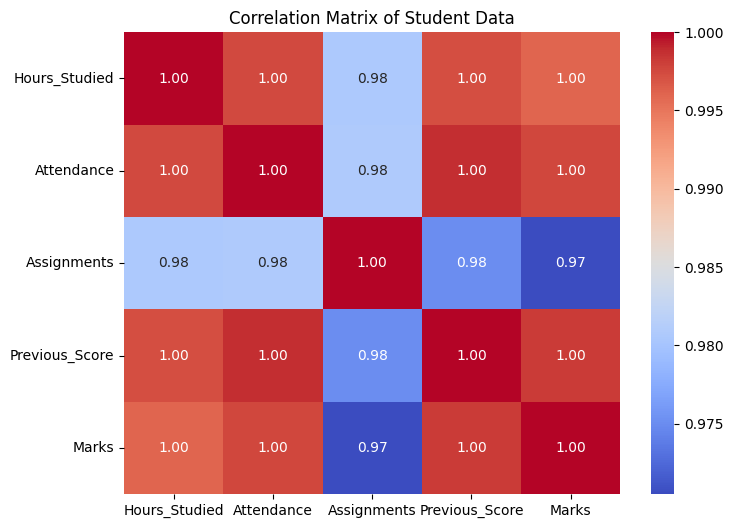

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix of Student Data')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


## Model A



In [ ]:
X_a = df[['Hours_Studied', 'Attendance', 'Assignments', 'Previous_Score']]
y = df['Marks']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a, y, test_size=0.2, random_state=42)

In [ ]:
model_a_split = LinearRegression()
start = time.perf_counter()
model_a_split.fit(X_train_a, y_train_a)
end = time.perf_counter()

In [ ]:
y_pred_a = model_a_split.predict(X_test_a)
r2_a = r2_score(y_test_a, y_pred_a)

In [ ]:
print("--- Model A (All Features) Evaluation ---")
print(f"R-squared on test set: {r2_a:.4f}")
print(f"Time taken to train : {(end - start):.4f}")

--- Model A (All Features) Evaluation ---
R-squared on test set: 0.9996
Time taken to train : 0.0024


## Model B

In [ ]:
X_b = df[['Hours_Studied', 'Previous_Score']]
y = df['Marks']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y, test_size=0.2, random_state=42)

In [ ]:
model_b_split = LinearRegression()
start = time.perf_counter()
model_b_split.fit(X_train_b, y_train_b)
end = time.perf_counter()

In [ ]:
y_pred_b = model_b_split.predict(X_test_b)
r2_b = r2_score(y_test_b, y_pred_b)

In [ ]:
print("\n--- Model B (Hours_Studied, Previous_Score) Evaluation ---")
print(f"R-squared on test set: {r2_b:.4f}")
print(f"Time taken to train : {(end - start):.4f}")


--- Model B (Hours_Studied, Previous_Score) Evaluation ---
R-squared on test set: 0.9991
Time taken to train : 0.0022


## New datasets

In [ ]:
import pandas as pd

data = {
    'Hours_Studied': [2, 4, 6, 8, 10, 5, 7, 3, 9, 6],
    'Attendance': [75, 80, 85, 90, 95, 82, 88, 78, 92, 86],
    'Assignments': [4, 5, 6, 7, 8, 5, 6, 4, 7, 6],
    'Previous_Score': [32, 45, 58, 72, 88, 52, 68, 40, 80, 62],
    'Favorite_Color': ['Blue', 'Red', 'Green', 'Blue', 'Yellow', 'Red', 'Blue', 'Green', 'Black', 'White'],
    'Classroom_Building': ['A', 'B', 'A', 'E', 'A', 'C', 'A', 'SC', 'G', 'A'],
    'Shoe_Size': [7.5, 9.0, 6.0, 8.5, 10.0, 7.0, 8.0, 9.5, 6.5, 11.0],
    'Student_Name': ['Liam', 'Olivia', 'Noah', 'Emma', 'Oliver', 'Ava', 'Elijah', 'Charlotte', 'William', 'Sophia'],
    'Mobile_Brand': ['Apple', 'Samsung', 'Google', 'OnePlus', 'Xiaomi', 'Apple', 'Samsung', 'Motorola', 'Nokia', 'Vivo'],
    'Marks': [35, 50, 65, 80, 95, 60, 75, 45, 88, 70]
}

df = pd.DataFrame(data)

In [ ]:
print("Correlation Matrix:")
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

Correlation Matrix:


,Hours_Studied,Attendance,Assignments,Previous_Score,Shoe_Size,Marks
Hours_Studied,1.000000,0.997498,0.980581,0.997298,0.026861,0.995991
Attendance,0.997498,1.000000,0.980771,0.998797,0.078208,0.997582
Assignments,0.980581,0.980771,1.000000,0.975097,0.084285,0.970491
Previous_Score,0.997298,0.998797,0.975097,1.000000,0.077259,0.998261
Shoe_Size,0.026861,0.078208,0.084285,0.077259,1.000000,0.069052
Marks,0.995991,0.997582,0.970491,0.998261,0.069052,1.000000


## Model A

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
X = df.drop(columns=['Marks','Student_Name'])
X_encoded = pd.get_dummies(X, columns=['Favorite_Color', 'Classroom_Building','Mobile_Brand'],drop_first=True)
y = df['Marks']

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [ ]:
model_a_new = LinearRegression()
start = time.perf_counter()
model_a_new.fit(X_train, y_train)
end = time.perf_counter()

In [ ]:
y_pred = model_a_new.predict(X_test)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("--- Model A (All Features) Evaluation ---")
print(f"R-squared on test set: {r2_a:.4f}")
print(f"Time taken to train : {(end - start):.4f}")

--- Model A (All Features) Evaluation ---
R-squared on test set: 0.9996
Time taken to train : 0.0024


## Model B


In [ ]:
X_b_new = df[['Hours_Studied', 'Attendance', 'Assignments', 'Previous_Score']]
y = df['Marks']

In [ ]:
X_train_b_new, X_test_b_new, y_train_b_new, y_test_b_new = train_test_split(X_b_new, y, test_size=0.2, random_state=42)

model_b_new = LinearRegression()
start = time.perf_counter()
model_b_new.fit(X_train_b_new, y_train_b_new)
end = time.perf_counter()

In [ ]:
y_pred_b_new = model_b_new.predict(X_test_b_new)
r2_b_new = r2_score(y_test_b_new, y_pred_b_new)

In [ ]:
print("--- Model B (Top 4 Correlated Features) Evaluation ---")
print(f"R-squared on test set: {r2_b_new:.4f}")
print(f"Time taken to train : {(end - start):.4f}")

--- Model B (Top 4 Correlated Features) Evaluation ---
R-squared on test set: 0.9996
Time taken to train : 0.0020
